In [1]:
import numpy as np
import matplotlib.pyplot as plt
import larp
import larp.io as lpio
import matplotlib.cm as cm

In [ ]:
edges = np.arange(0.2, 0.8, 0.2)

field = lpio.loadRGeoJSONFile("walled_room.rgj", size_offset=10)
quadtree = larp.quad.QuadTree(field=field,
                                minimum_length_limit=2,
                                edge_bounds=edges,
                                build_tree=True)
qfield = larp.QPotentailField(quadtree)


In [3]:
def plot():
    # Generate the field image
    display, extent = qfield.to_image(resolution=400, return_extent=True)
    # Create figure and subplots
    _, axs = plt.subplots(1, 2, sharey=True, dpi=150)
    # Plot the field image on first subplot
    img = axs[0].imshow(display, cmap='jet', extent=extent)
    img.set_clim(0.0, 1.0)  # Correct way to set color limits
    # Plot the field image again on second subplot
    img = axs[1].imshow(display, cmap='jet', extent=extent)
    img.set_clim(0.0, 1.0)
    # Get edge boundaries and zones from quadtree
    edge_bounds_lines = quadtree.to_boundary_lines_collection(margin=0.2)
    edge_bounds_lines_zones = quadtree.get_quad_zones()
    # Plot boundaries with zone-based colors
    for i in range(0, len(edge_bounds_lines), 2):
        zone = edge_bounds_lines_zones[i // 2]
        c = cm.jet(quadtree.ZONEToMaxRANGE[zone]) if zone > 0 else "#e4ebff"
        axs[1].plot(*edge_bounds_lines[i:i+2], c=c, alpha=1, linewidth=1)

    plt.tight_layout()
    plt.show()

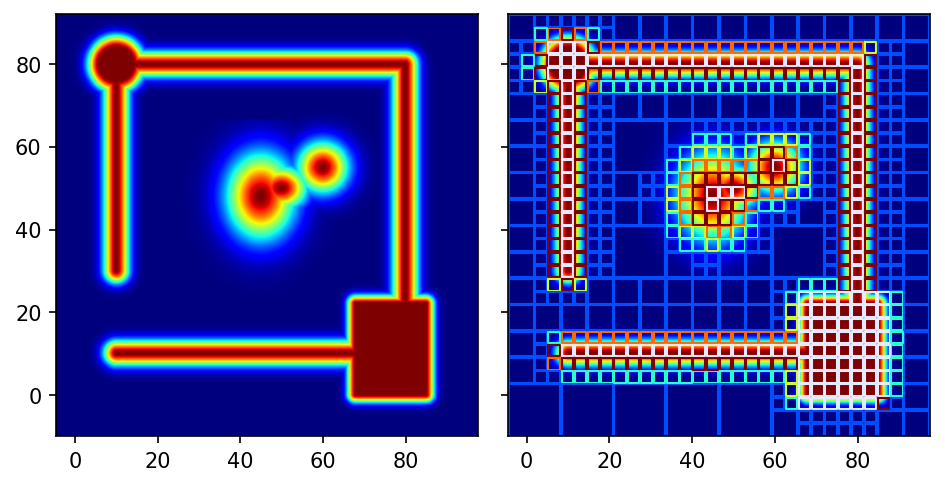

In [ ]:
plot()

## Add 1000 points
points = larp.PotentialField([larp.PointRGJ(np.random.rand(2)*(75-15)+15, repulsion=[[10, 0], [0, 10]]) for _ in range(1000)])

In [5]:
%time added_idxs = qfield.addField(points)

CPU times: total: 688 ms
Wall time: 688 ms


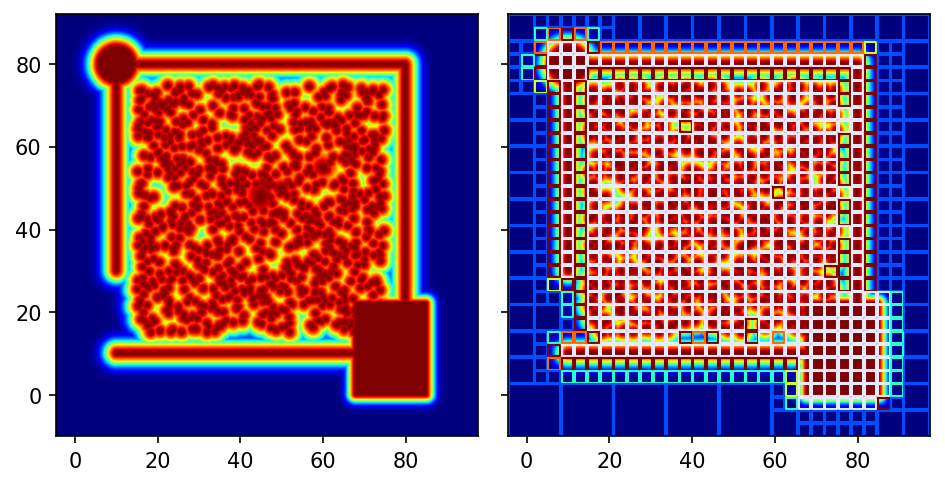

In [6]:
plot()

In [7]:
# Remove RGJs
%time qfield.delRGJ(added_idxs)

CPU times: total: 31.2 ms
Wall time: 41.1 ms


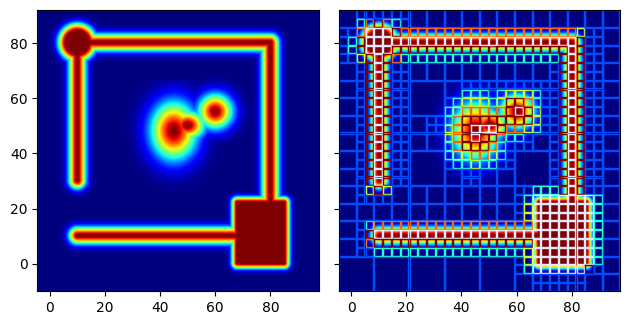

In [8]:
# Create figure and subplots
fig, axs = plt.subplots(1, 2, sharey=True, dpi=100)

# Generate the field image
display, extent = qfield.to_image(resolution=400, return_extent=True)
# Plot the field image on first subplot
img = axs[0].imshow(display, cmap='jet', extent=extent)
img.set_clim(0.0, 1.0)  # Correct way to set color limits
# Plot the field image again on second subplot
img = axs[1].imshow(display, cmap='jet', extent=extent)
img.set_clim(0.0, 1.0)
# Get edge boundaries and zones from quadtree
edge_bounds_lines = quadtree.to_boundary_lines_collection(margin=0.2)
edge_bounds_lines_zones = quadtree.get_quad_zones()
# Plot boundaries with zone-based colors
for i in range(0, len(edge_bounds_lines), 2):
    zone = edge_bounds_lines_zones[i // 2]
    c = cm.jet(quadtree.ZONEToMaxRANGE[zone]) if zone > 0 else "#e4ebff"
    axs[1].plot(*edge_bounds_lines[i:i+2], c=c, alpha=1, linewidth=1)

plt.tight_layout()
plt.show()

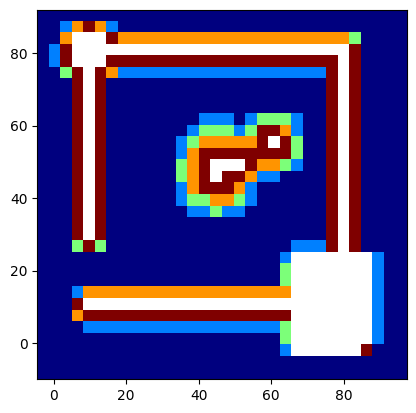

In [10]:
# Create figure and subplots
fig, ax = plt.subplots(sharey=True, dpi=100)

# Generate the field image
display, extent = quadtree.to_image(return_potential=False, return_extent=True) # Need to improve
masked_display = quadtree.ZONEToMaxRANGE[display]
masked_display[display == 0] = np.nan

# Plot the quad sectors image
img = ax.imshow(masked_display, cmap='jet', extent=extent)
